Nama : Rangga Saputra

NIM : 250401020034

Kelas : IF405

---

# Praktikum Pertemuan 5: Visualisasi Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

Shape dataset: (244, 7)

Tipe data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Text(0.5, 0.01, 'Sumber: Dataset "tips" dari Seaborn  |  Visualisasi: Matplotlib & Seaborn  |  Pertemuan 5 — Data Science')

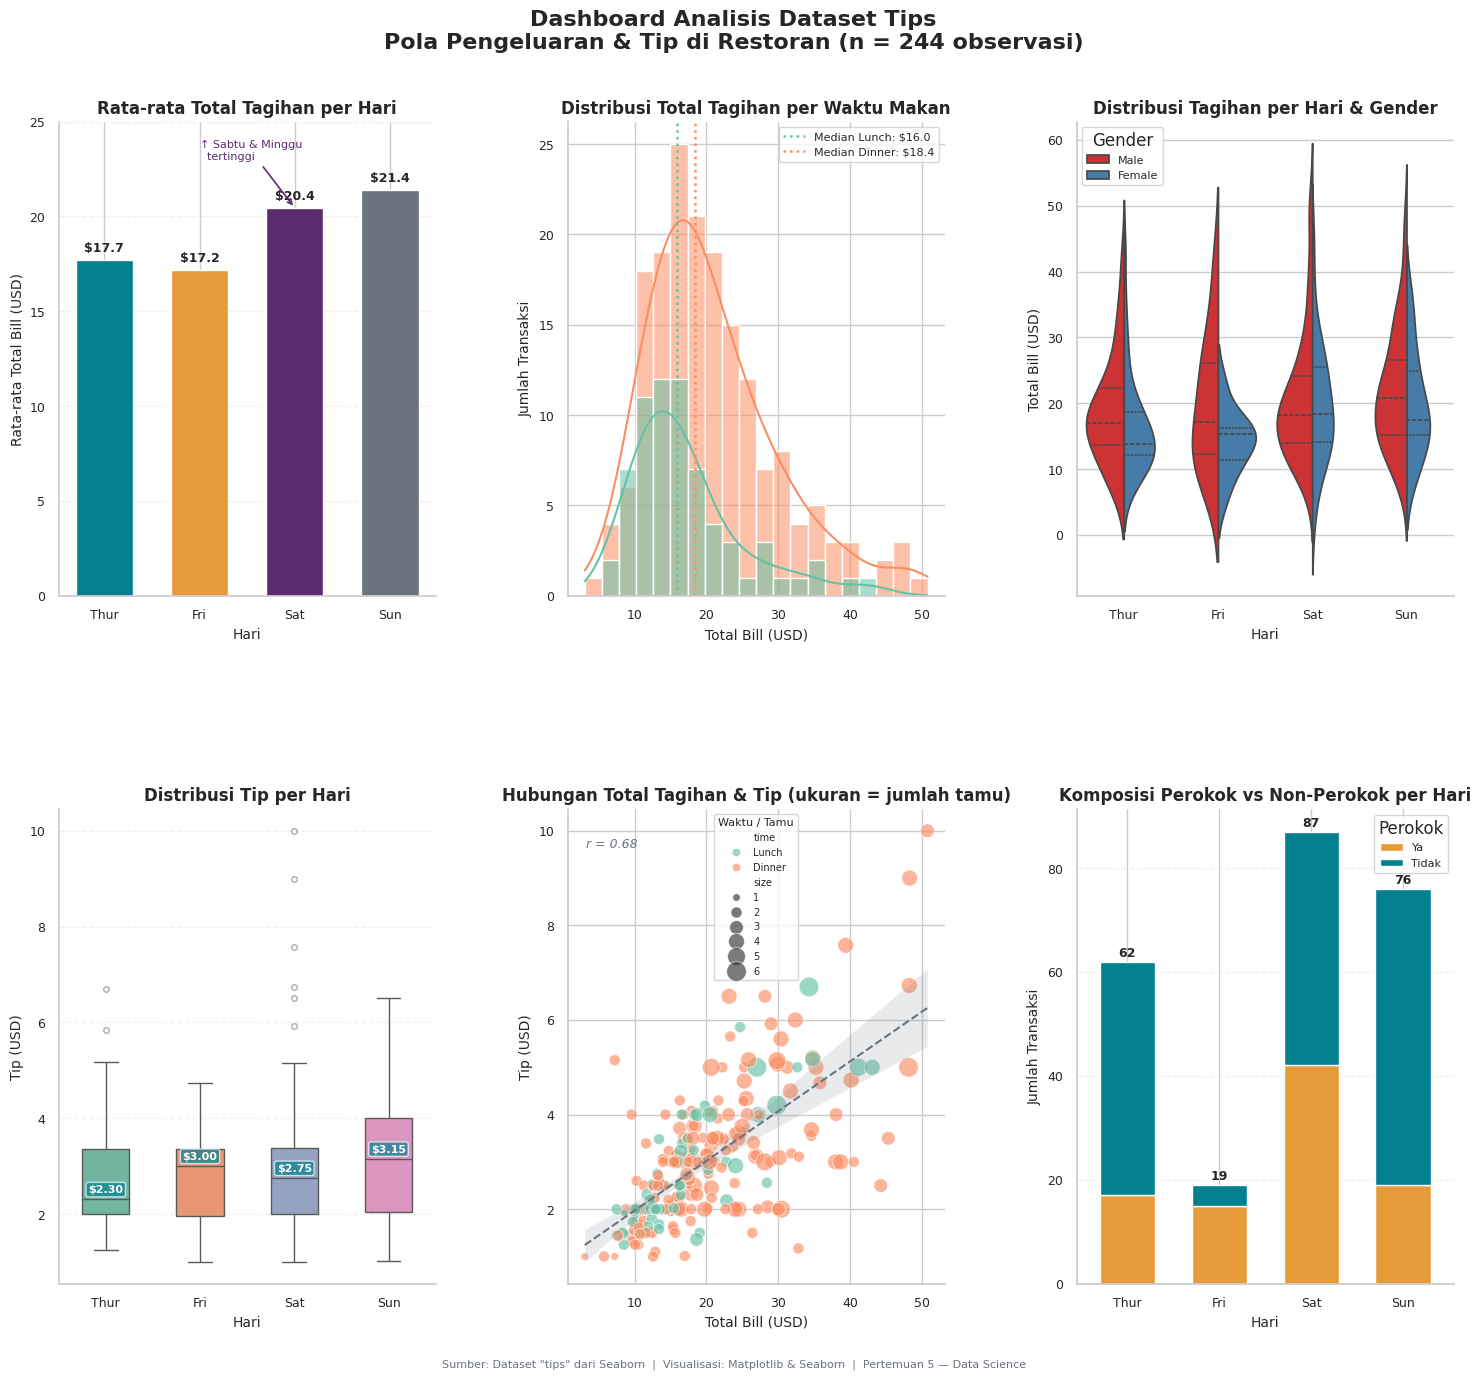

In [2]:
# ── 1. LOAD & INSPECT DATASET ─────────────────────────────────────────
df = sns.load_dataset('tips')
print("=" * 50)
print(f"Shape dataset: {df.shape}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nStatistik deskriptif:\n{df.describe().round(2)}")
print("=" * 50)

# ── 2. SETUP GLOBAL STYLE ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'teal':   '#028090',
    'amber':  '#E69B3A',
    'purple': '#5B2C6F',
    'gray':   '#6B7280',
}

# ── 3. SETUP FIGURE LAYOUT ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Dashboard Analisis Dataset Tips\n'
    'Pola Pengeluaran & Tip di Restoran (n = 244 observasi)',
    fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.45, wspace=0.35,
    top=0.90, bottom=0.07
)

ax1 = fig.add_subplot(gs[0, 0])   # Bar chart
ax2 = fig.add_subplot(gs[0, 1])   # Histogram + KDE
ax3 = fig.add_subplot(gs[0, 2])   # Violin plot
ax4 = fig.add_subplot(gs[1, 0])   # Boxplot
ax5 = fig.add_subplot(gs[1, 1])   # Scatter plot
ax6 = fig.add_subplot(gs[1, 2])   # Stacked bar (komposisi)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 1 — Bar Chart: Rata-rata Tagihan per Hari
# ─────────────────────────────────────────────────────────────────────
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean().reindex(day_order)

bars = ax1.bar(
    avg_by_day.index, avg_by_day.values,
    color=[COLORS['teal'], COLORS['amber'], COLORS['purple'], COLORS['gray']],
    edgecolor='white', width=0.6
)
ax1.bar_label(bars, fmt='$%.1f', padding=4, fontsize=9, fontweight='bold')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Total Bill (USD)')
ax1.set_ylim(0, 25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Anotasi insight
ax1.annotate(
    '↑ Sabtu & Minggu\n  tertinggi',
    xy=('Sat', avg_by_day['Sat']),
    xytext=('Fri', 23),
    fontsize=8, color=COLORS['purple'],
    arrowprops=dict(arrowstyle='->', color=COLORS['purple'], lw=1.2)
)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 2 — Histogram + KDE: Distribusi Total Tagihan per Waktu Makan
# ─────────────────────────────────────────────────────────────────────
sns.histplot(
    data=df, x='total_bill', hue='time',
    kde=True, palette='Set2', alpha=0.55,
    bins=20, ax=ax2
)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Jumlah Transaksi')
ax2.spines[['top', 'right']].set_visible(False)

# Garis median
for label, color in zip(['Lunch', 'Dinner'], ['#66C2A5', '#FC8D62']):
    med = df[df['time'] == label]['total_bill'].median()
    ax2.axvline(med, color=color, linestyle=':', linewidth=1.8,
                label=f'Median {label}: ${med:.1f}')
ax2.legend(fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 3 — Violin Plot: Distribusi Tagihan per Hari & Gender
# ─────────────────────────────────────────────────────────────────────
sns.violinplot(
    data=df, x='day', y='total_bill',
    hue='sex', palette='Set1',
    order=day_order, split=True,
    inner='quartile', ax=ax3
)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(title='Gender', fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 4 — Boxplot: Perbandingan Tip per Hari
# ─────────────────────────────────────────────────────────────────────
sns.boxplot(
    data=df, x='day', y='tip',
    order=day_order,
    palette='Set2', width=0.5, hue='day', legend=False, ax=ax4,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
ax4.set_title('Distribusi Tip per Hari')
ax4.set_xlabel('Hari')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Tandai median
for i, day in enumerate(day_order):
    med = df[df['day'] == day]['tip'].median()
    ax4.text(i, med + 0.1, f'${med:.2f}',
             ha='center', va='bottom', fontsize=8, color='white',
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor=COLORS['teal'], alpha=0.7))

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 5 — Scatter Plot: Hubungan Tagihan & Tip
# ─────────────────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='total_bill', y='tip',
    hue='time', size='size',
    sizes=(30, 200), palette='Set2',
    alpha=0.65, ax=ax5
)
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter=False, color=COLORS['gray'],
    line_kws={'linestyle': '--', 'linewidth': 1.5},
    ax=ax5
)

# Hitung korelasi
corr = df[['total_bill', 'tip']].corr().iloc[0, 1]
ax5.text(0.05, 0.92, f'r = {corr:.2f}',
         transform=ax5.transAxes, fontsize=9,
         color=COLORS['gray'], style='italic')

ax5.set_title('Hubungan Total Tagihan & Tip (ukuran = jumlah tamu)')
ax5.set_xlabel('Total Bill (USD)')
ax5.set_ylabel('Tip (USD)')
ax5.spines[['top', 'right']].set_visible(False)
ax5.legend(title='Waktu / Tamu', fontsize=7, title_fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 6 — Stacked Bar: Komposisi Perokok vs Non-Perokok per Hari
# ─────────────────────────────────────────────────────────────────────
smoker_counts = df.groupby(['day', 'smoker'], observed=False).size().unstack(fill_value=0)
smoker_counts = smoker_counts.reindex(day_order)

smoker_counts.plot(
    kind='bar', stacked=True, ax=ax6,
    color=[COLORS['amber'], COLORS['teal']],
    edgecolor='white', width=0.6
)
ax6.set_title('Komposisi Perokok vs Non-Perokok per Hari')
ax6.set_xlabel('Hari')
ax6.set_ylabel('Jumlah Transaksi')
ax6.tick_params(axis='x', rotation=0)
ax6.spines[['top', 'right']].set_visible(False)
ax6.legend(title='Perokok', labels=['Ya', 'Tidak'], fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

# Label total di atas tiap bar
totals = smoker_counts.sum(axis=1)
for i, total in enumerate(totals):
    ax6.text(i, total + 0.5, str(int(total)),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 4. FOOTER ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    'Sumber: Dataset "tips" dari Seaborn  |  Visualisasi: Matplotlib & Seaborn  |  Pertemuan 5 — Data Science',
    ha='center', fontsize=8, color=COLORS['gray']
)

In [3]:
import os

# ── 5. EKSPOR ─────────────────────────────────────────────────────────
output_path = '/content/dashboard_tips.png'

# Create the directory if it doesn't exist
output_dir = os.path.dirname(output_path)
# Only create directory if output_path includes a directory (i.e., not just a filename)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"\n✅ Dashboard berhasil disimpan: {output_path}")


✅ Dashboard berhasil disimpan: /content/dashboard_tips.png


# Penjelasan 6 Grafik Dashboard

## Grafik 1 Bar Chart: Rata-rata Tagihan per Hari
Grafik batang yang membandingkan berapa rata-rata uang yang dikeluarkan pelanggan di tiap hari.

Sabtu dan Minggu punya tagihan tertinggi (~$20).

Sedangkan Jumat paling rendah (~$17).

Artinya: Orang lebih banyak keluar makan di akhir pekan, kemungkinan bersama keluarga atau teman, sehingga memesan lebih banyak.

---

## Grafik 2 Histogram + KDE: Distribusi Tagihan per Waktu Makan
Grafik yang menunjukkan seberapa sering tagihan bernilai tertentu, dibedakan antara makan siang (Lunch) dan makan malam (Dinner).

Mayoritas tagihan berada di kisaran `$10–$20`. Makan malam lebih tersebar ke nilai tinggi dibanding makan siang.

Artinya: Pelanggan makan malam cenderung memesan lebih mahal. Garis KDE (kurva halus di atas histogram) memperlihatkan bentuk distribusinya lebih jelas.

---

## Grafik 3 Violin Plot: Tagihan per Hari & Gender
Bentuknya seperti biola, semakin lebar bagian tertentu, semakin banyak data di nilai itu. Dibagi dua antara pria (kanan) dan wanita (kiri).

Pria umumnya memiliki tagihan lebih bervariasi dan lebih tinggi dibanding wanita di semua hari.

Artinya: Ada perbedaan pola belanja berdasarkan gender, terutama di akhir pekan.

---

## Grafik 4 Boxplot: Distribusi Tip per Hari
Setiap kotak merangkum sebaran nilai tip dalam satu hari. Garis tengah kotak = nilai median, batas kotak = Q1 dan Q3, titik di luar = outlier (tip yang sangat besar atau kecil).

Median tip cukup konsisten di semua hari (~$2.9), tapi Sabtu dan Minggu punya lebih banyak outlier tip besar.

Artinya: Di akhir pekan sesekali ada pelanggan yang memberi tip sangat besar, kemungkinan dari meja dengan jumlah tamu banyak.

---

## Grafik 5 Scatter Plot: Hubungan Tagihan & Tip
Setiap titik = satu transaksi. Posisi menunjukkan besar tagihan (X) vs besar tip (Y). Ukuran titik = jumlah tamu di meja.

Garis regresi menanjak ke kanan dengan nilai r = 0.68, artinya semakin besar tagihan, semakin besar tip hubungannya cukup kuat. Titik besar (meja ramai) umumnya ada di tagihan tinggi.

Artinya: Tip sangat dipengaruhi total tagihan, bukan sekadar kebaikan hati pelanggan.

---

## Grafik 6 Stacked Bar: Komposisi Perokok per Hari
Bar ditumpuk bagian bawah = non-perokok, bagian atas = perokok. Tinggi total bar = total transaksi hari itu.

Sabtu punya transaksi terbanyak (87 transaksi). Proporsi perokok relatif konsisten sekitar 30–40% di semua hari.

Artinya: Restoran ramai di Sabtu. Jika restoran ingin membuat kebijakan area bebas rokok, perlu mempertimbangkan bahwa hampir sepertiga pelanggan adalah perokok.

---

## Kesimpulan:

### Apa yang Dipelajari
- Di pertemuan ini saya belajar membuat **dashboard visualisasi** yang berisi 6 grafik sekaligus dalam satu gambar, menggunakan dataset `tips` data nyata dari transaksi restoran dengan 244 catatan
- Belajar cara mengatur tata letak banyak grafik sekaligus pakai `GridSpec`, memilih jenis grafik yang tepat untuk pertanyaan yang berbeda
(bar chart, histogram, violin plot, boxplot, scatter plot, dan stacked bar), serta mempercantik tampilan grafik dengan warna kustom, anotasi, dan label yang informatif.
- Secara keseluruhan, dataset tips ini menggambarkan bahwa waktu makan dan hari kunjungan adalah faktor terbesar yang memengaruhi pola pengeluaran pelanggan di restoran ini.

### Temuan Utama
- **Akhir pekan = ramai dan mahal.** Sabtu dan Minggu adalah hari dengan tagihan rata-rata tertinggi, karena orang lebih sering makan bersama keluarga atau teman di akhir pekan.
- **Tip sangat dipengaruhi total tagihan.** Korelasi antara keduanya cukup kuat (r = 0.68), artinya pelanggan yang bayar lebih mahal cenderung memberi tip lebih besar juga.
- **Makan malam lebih "royal" dari makan siang.** Distribusi tagihan makan malam lebih menyebar ke nilai tinggi dibanding makan siang.
- **Hampir sepertiga pelanggan adalah perokok** di semua hari, informasi yang berguna kalau restoran mau membuat kebijakan area merokok.

### Keterbatasan & Pertanyaan yang Muncul
- Sudah cukup informatif, tapi semua analisanya masih bersifat deskriptif, hanya menggambarkan apa yang terjadi belum menjelaskan
*mengapa*.
- Apakah pola yang sama akan muncul di restoran yang berbeda, atau ini hanya khas restoran tertentu saja?